In [2]:
# =========================================================
# EDA - Reproducing Table S1 (ordered + transposed)
# =========================================================

import pandas as pd

# --- 1) Load dataset ---
file_path = "https://raw.githubusercontent.com/sarvelos/synthetic-bee-communities/main/merged_audio_features.xlsx"
df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)

# --- 2) Explicit feature list in Table S1 order ---

FEATURES = [
    # Core acoustic features
    'centroid', 'bandwidth', 'rolloff', 'flatness', 'zcr',
    'energy', 'entropy', 'f0_yin_mean',
    'spectral_contrast', 'rms_energy',

    # MFCC block (1–13)
]

# Add MFCC-derived features in correct sequence
for i in range(1, 14):
    FEATURES.extend([
        f'mfcc_{i}',
        f'mfcc_sd_{i}',
        f'mfcc_kurt_{i}',
        f'delta_{i}',
        f'delta2_{i}',
    ])

# --- 3) Subset dataframe in correct order ---
df_features = df[FEATURES]

# --- 4) Generate descriptive statistics ---
table_s1 = df_features.describe()

# --- 5) Transpose (features as rows) ---
table_s1 = table_s1.T

# --- 6) Optional: round for manuscript formatting ---
table_s1 = table_s1.round(2)

display(table_s1)

# --- 7) Save ---
output_path = "/content/Table_S1_reproduced.xlsx"
table_s1.to_excel(output_path)

print(f"Saved: {output_path}")

Dataset shape: (396, 80)


,count,mean,std,min,25%,50%,75%,max
centroid,396.0,6479.13,1619.36,558.02,5598.23,6639.64,7626.46,9910.30
bandwidth,396.0,5056.43,794.39,1514.87,4641.92,5257.19,5632.63,6792.95
rolloff,396.0,12274.26,2176.70,494.52,11190.79,12744.58,13714.59,16337.76
flatness,396.0,0.05,0.04,0.00,0.01,0.03,0.07,0.24
zcr,396.0,0.18,0.11,0.01,0.09,0.17,0.27,0.42
...,...,...,...,...,...,...,...,...
mfcc_13,396.0,-11.33,8.10,-37.43,-15.35,-10.07,-6.12,11.08
mfcc_sd_13,396.0,5.23,1.23,2.47,4.25,5.11,5.90,9.66
mfcc_kurt_13,396.0,0.06,0.91,-1.19,-0.48,-0.18,0.35,6.33
delta_13,396.0,-0.02,0.15,-0.81,-0.08,-0.00,0.07,0.34


Saved: /content/Table_S1_reproduced.xlsx


Saved correlation matrix: /content/pearson_correlation_matrix.xlsx


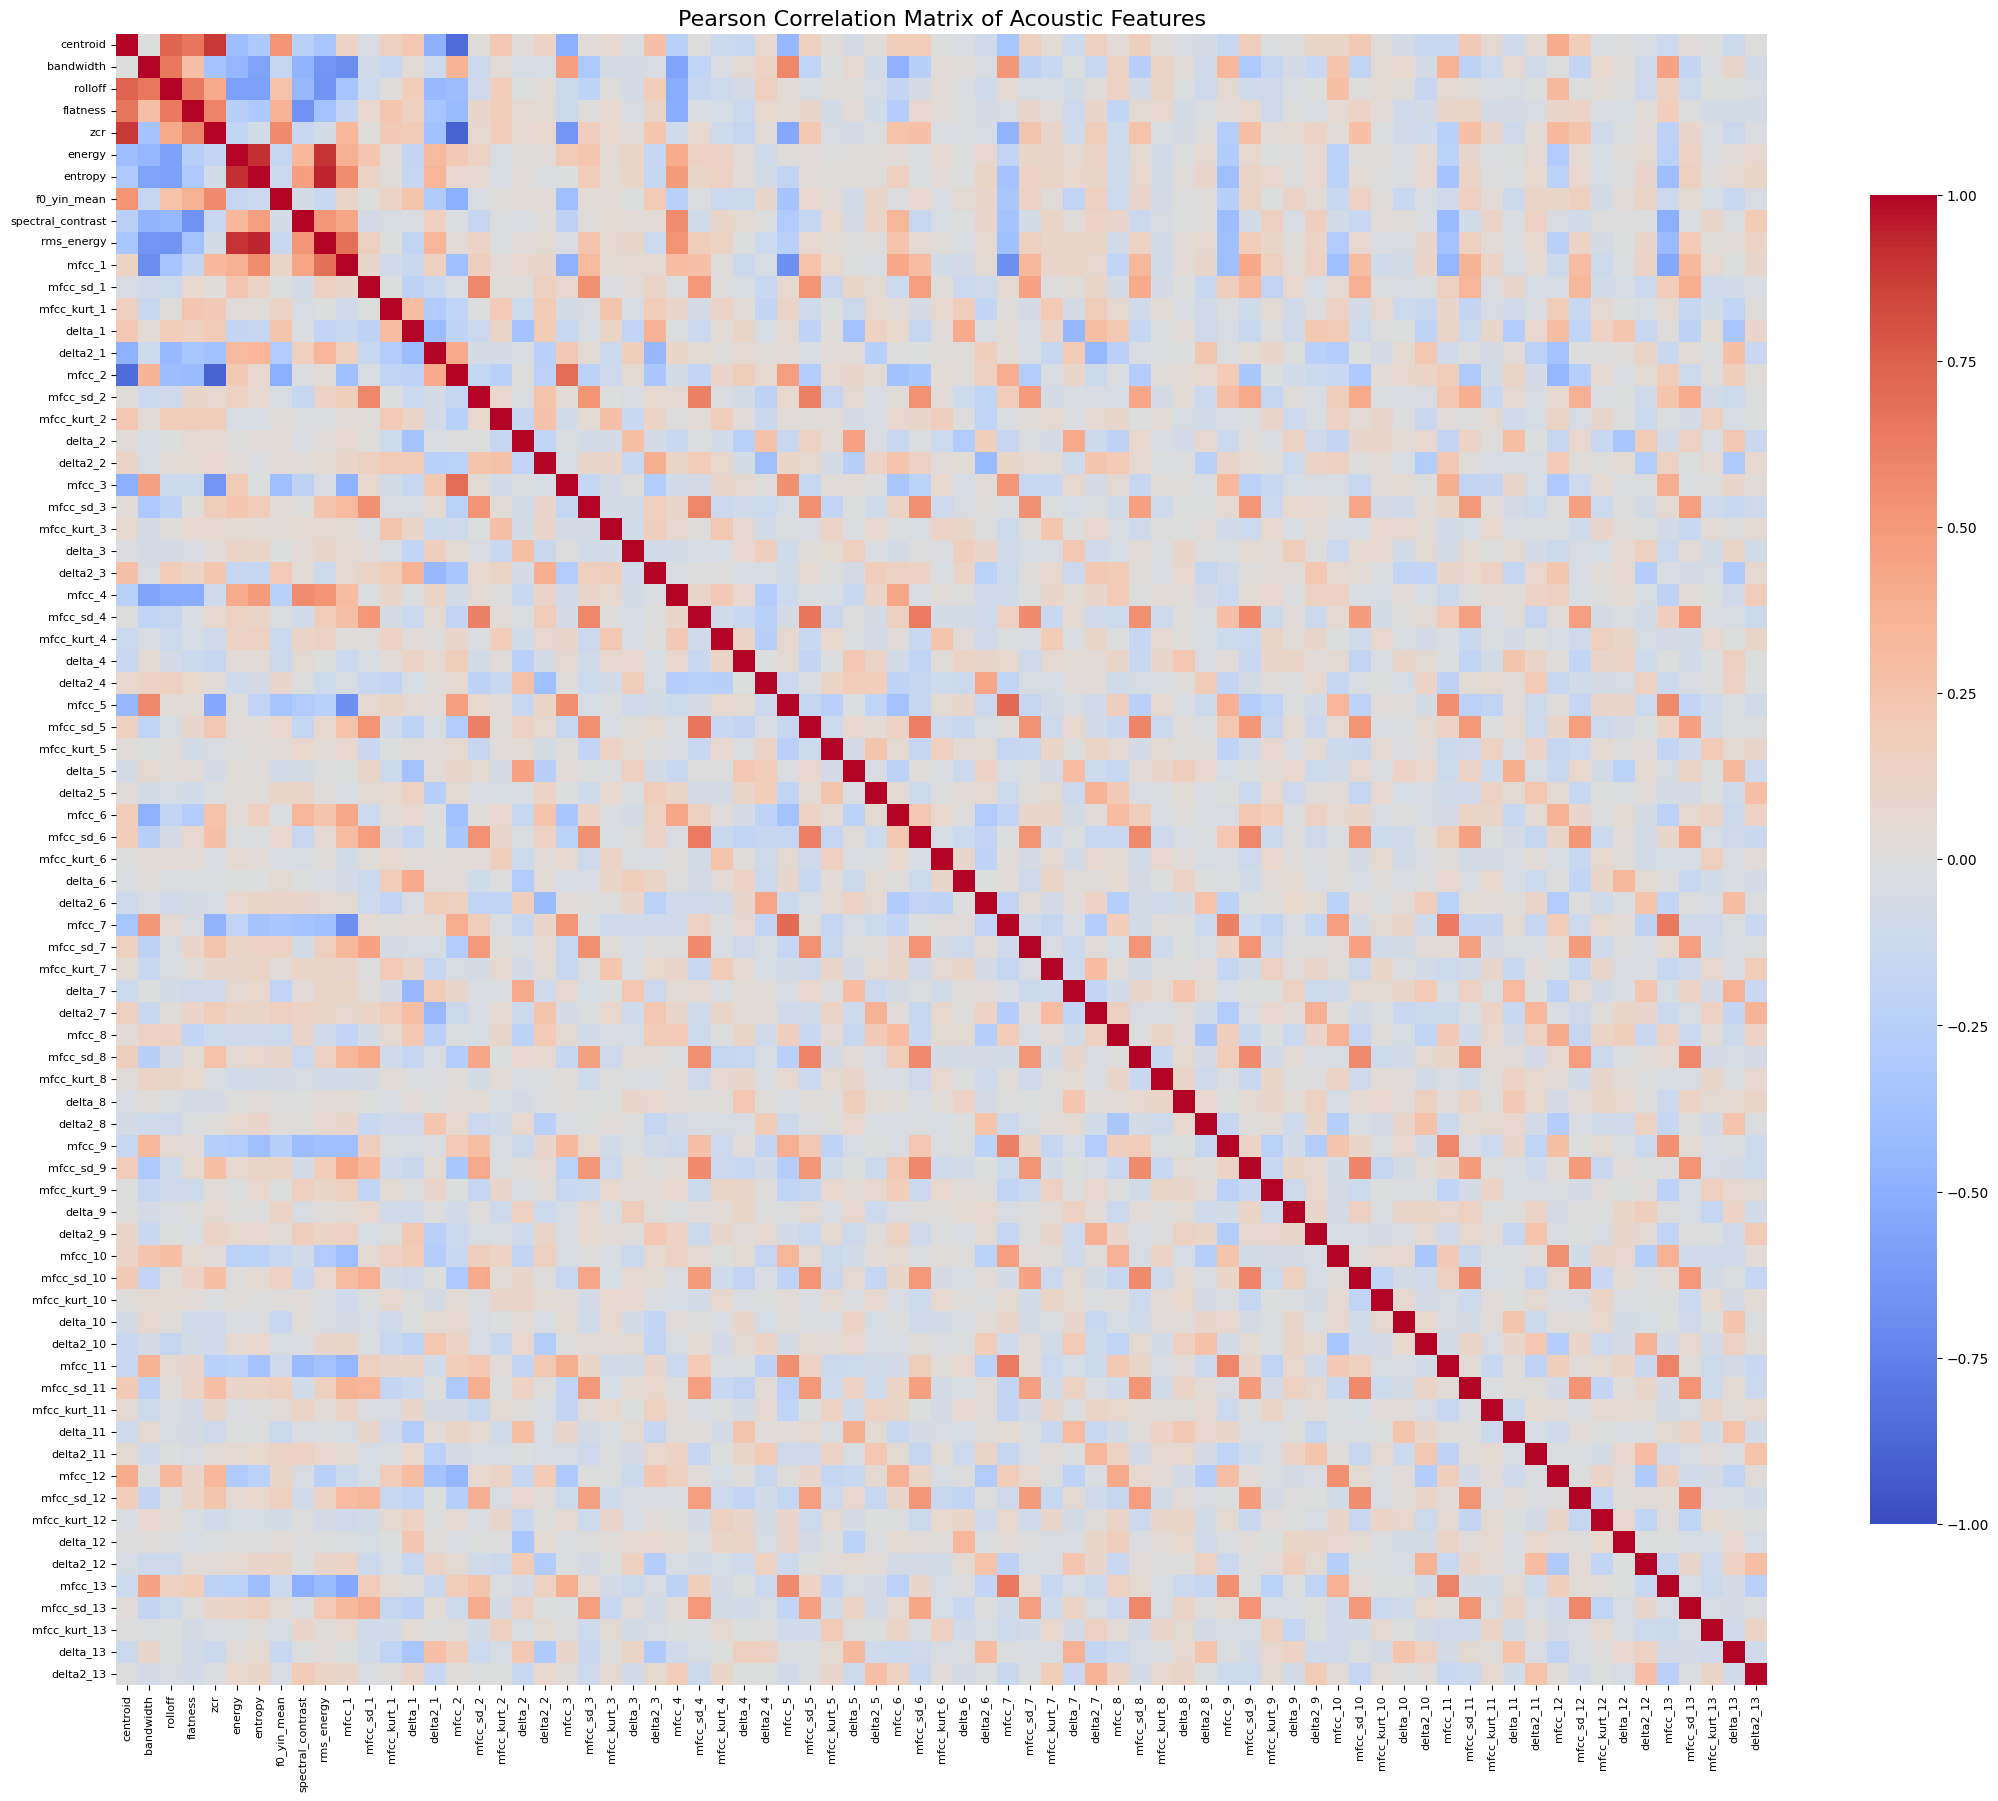

Saved full heatmap: /content/pearson_heatmap_full.png


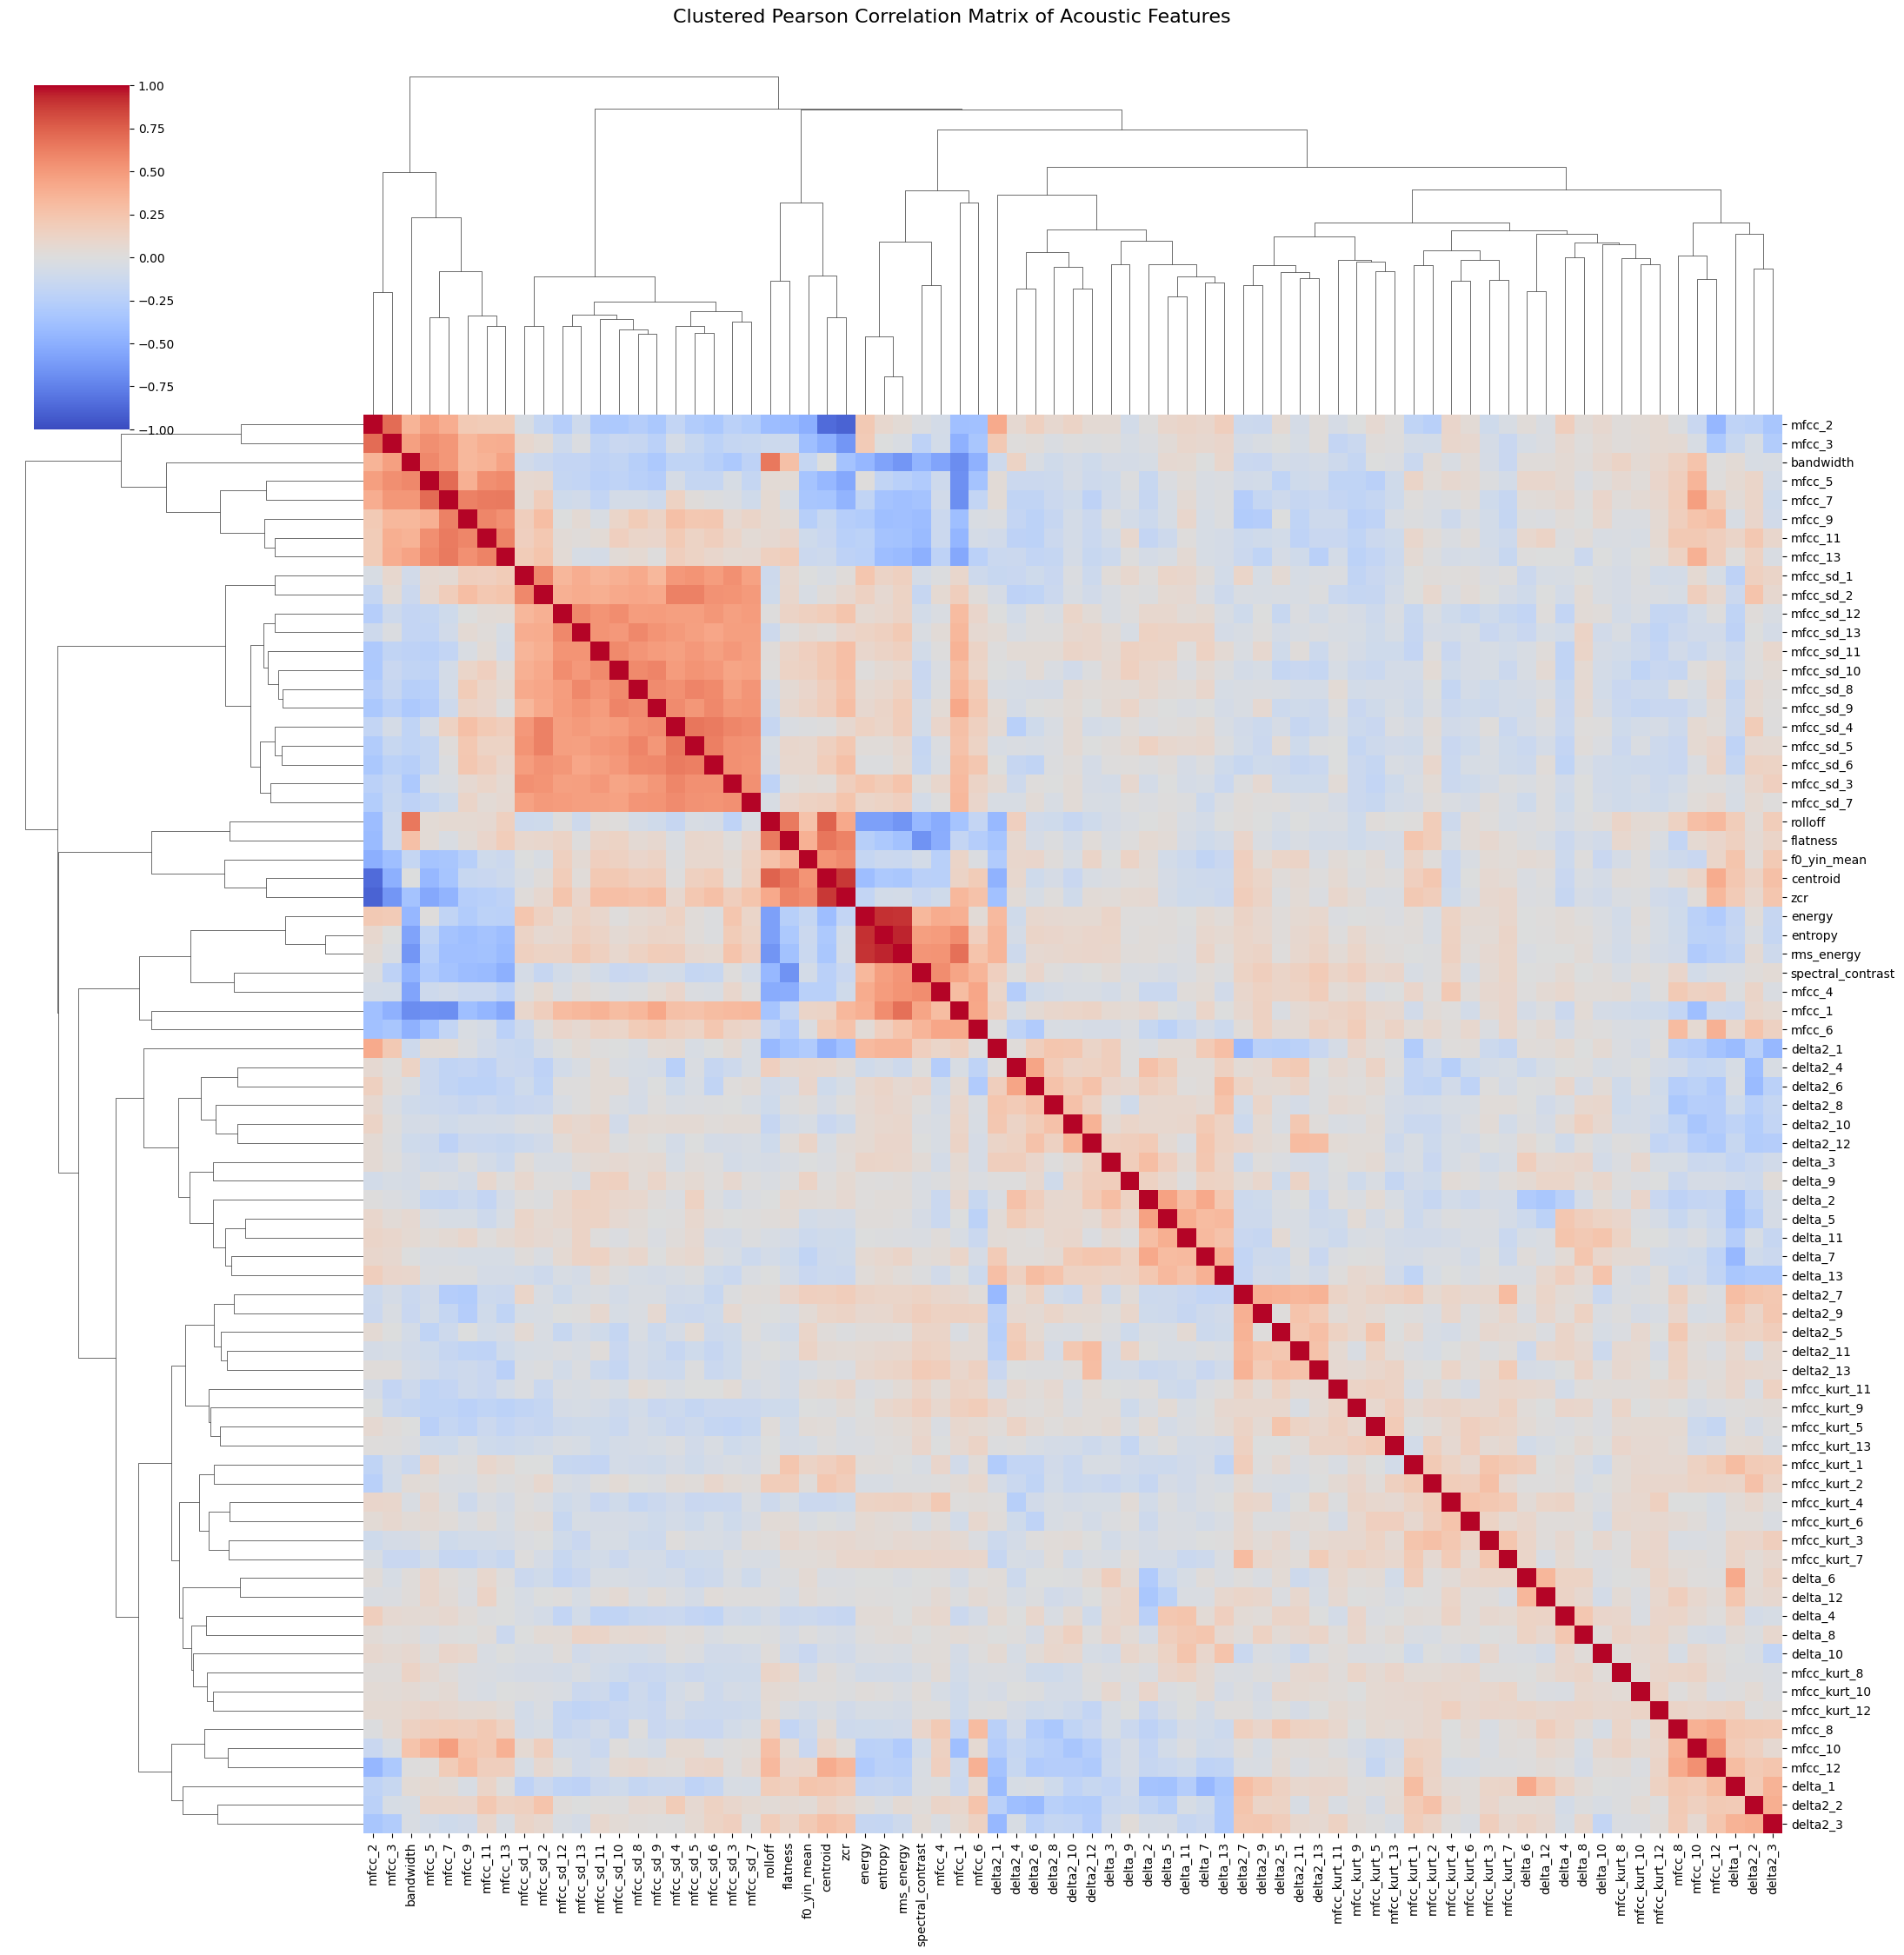

Saved clustered heatmap: /content/pearson_heatmap_clustered.png


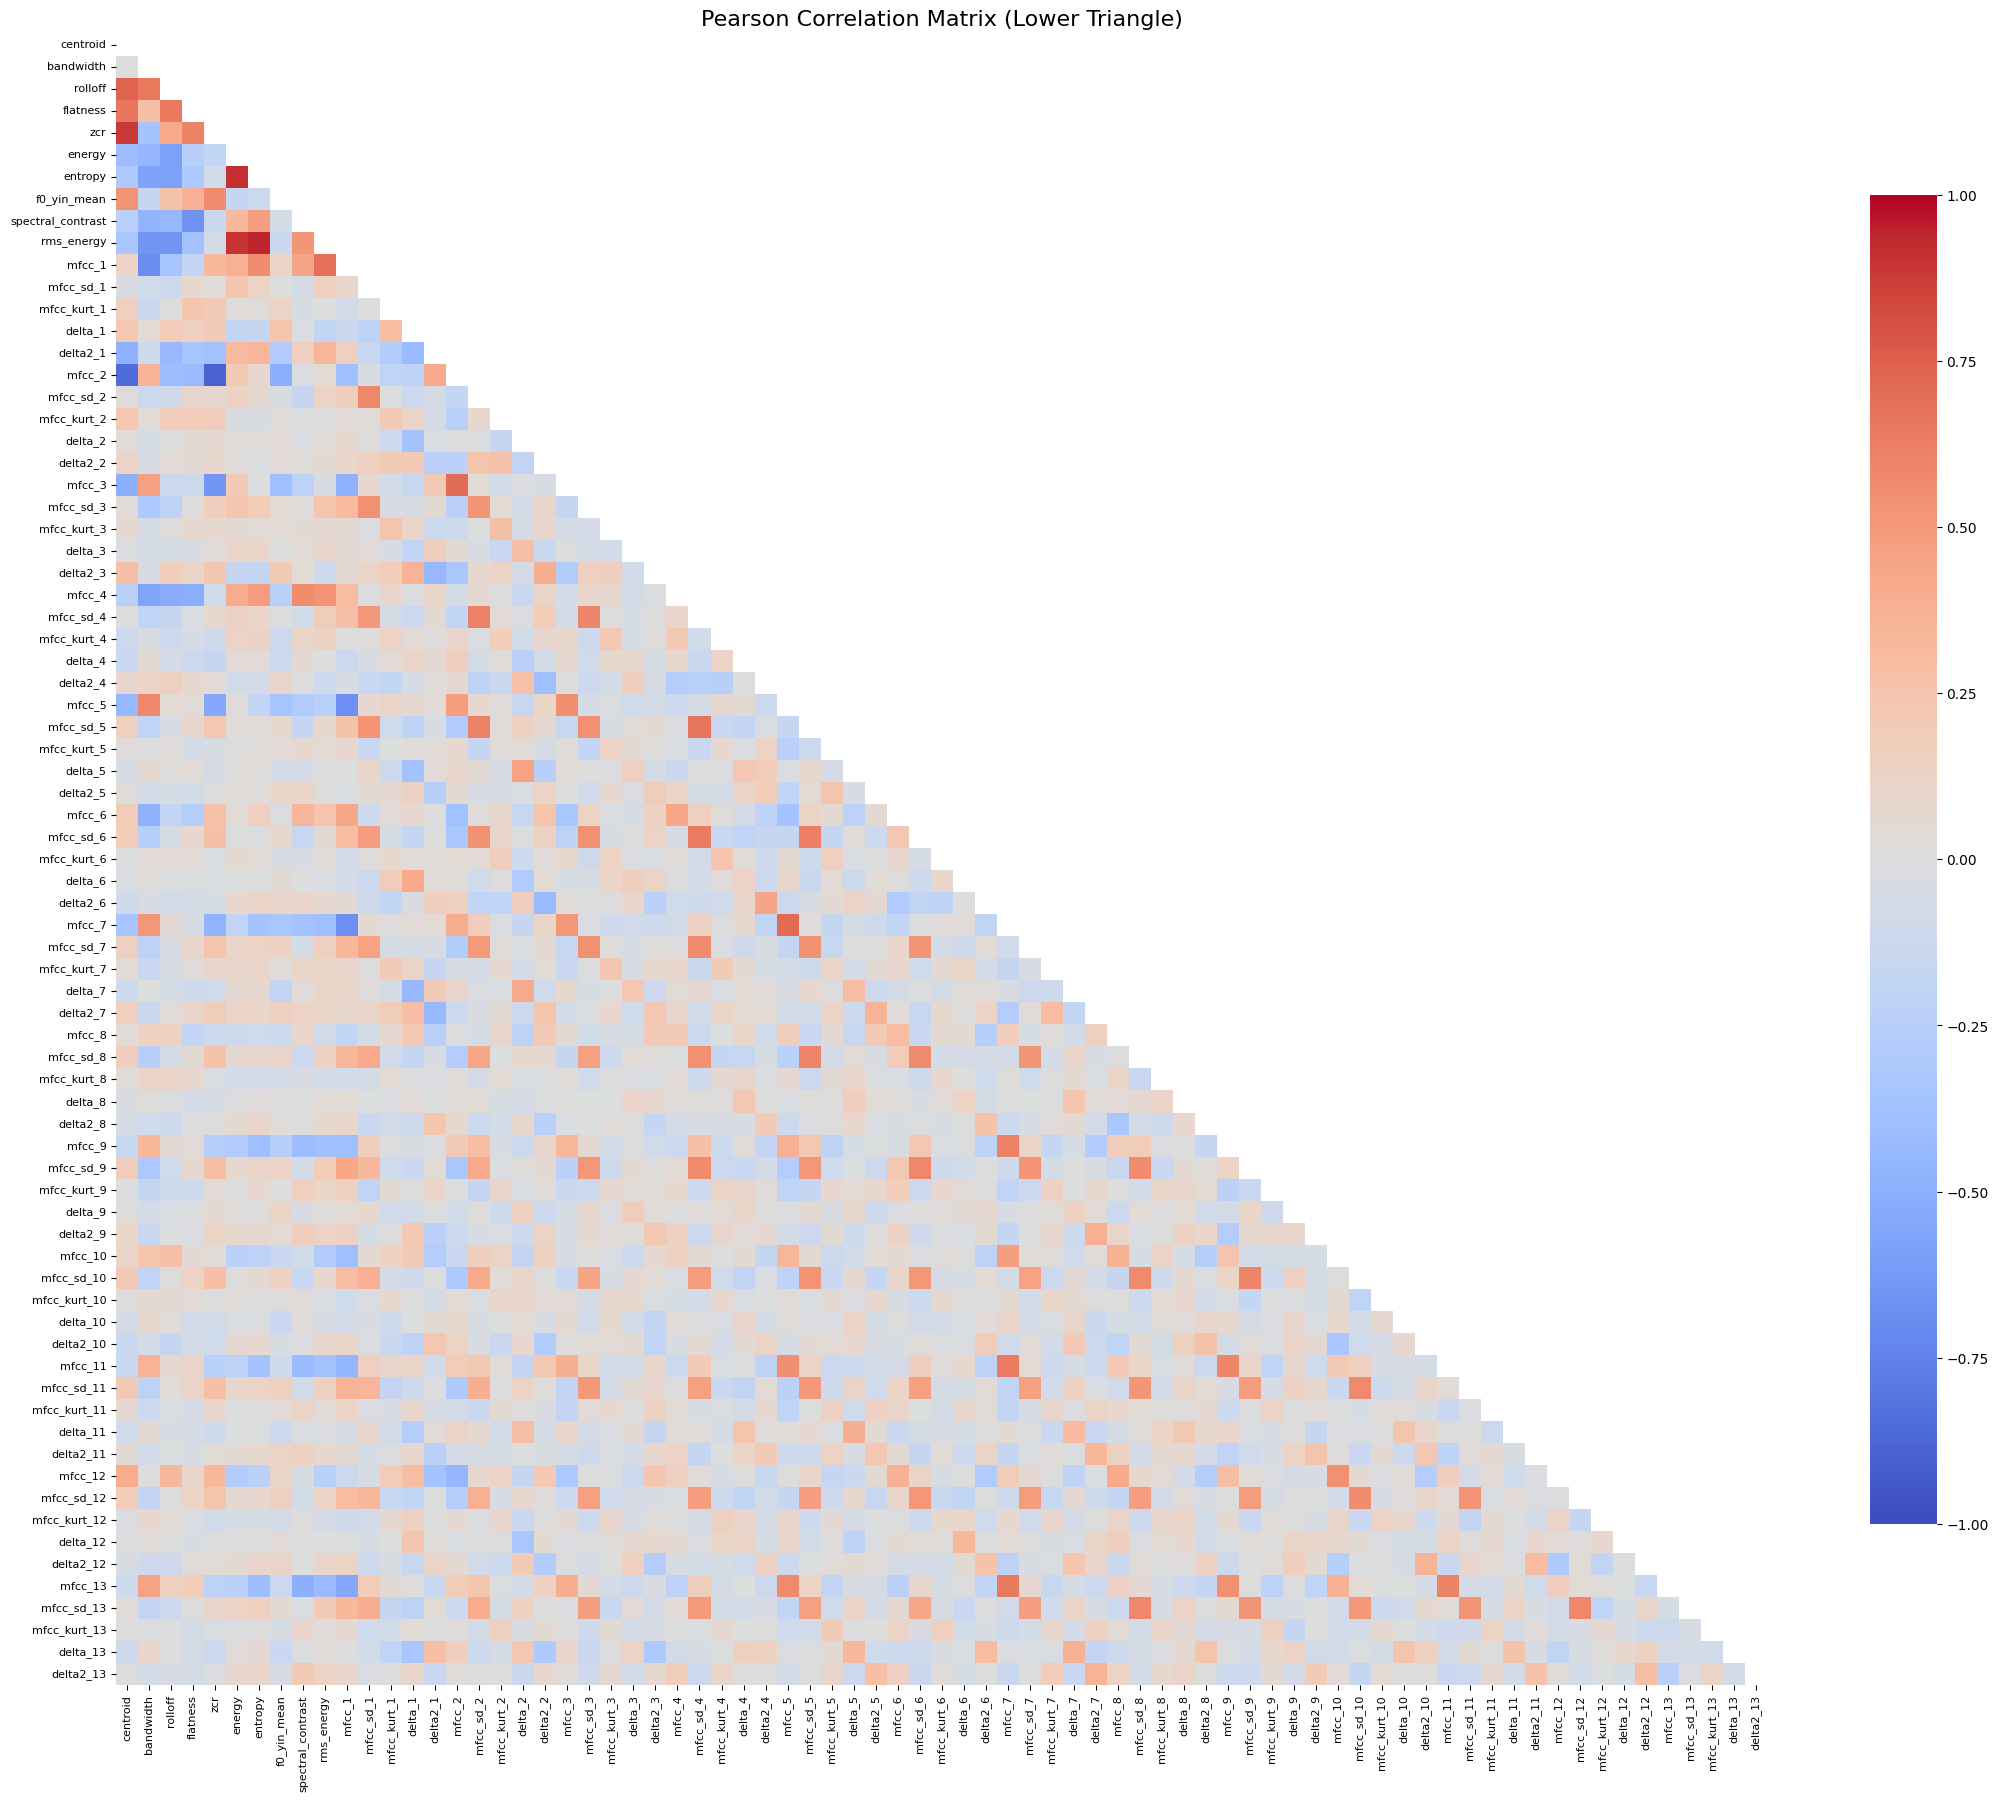

Saved lower-triangle heatmap: /content/pearson_heatmap_triangle.png


,Feature_1,Feature_2,|r|
431,entropy,rms_energy,0.944847
360,energy,entropy,0.909381
363,energy,rms_energy,0.903819
300,zcr,mfcc_2,0.891796
3,centroid,zcr,0.888885
14,centroid,mfcc_2,0.853032


Saved highly correlated pairs: /content/highly_correlated_pairs_r_gt_0_8.xlsx


In [3]:
# --- 8) Compute Pearson correlation matrix ---
corr_matrix = df_features.corr(method="pearson")

# --- 9) Save correlation matrix ---
corr_output = "/content/pearson_correlation_matrix.xlsx"
corr_matrix.to_excel(corr_output)

print(f"Saved correlation matrix: {corr_output}")

# --- 10) Full Pearson heatmap (ordered as Table S1) ---
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Matrix of Acoustic Features", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

heatmap_full_path = "/content/pearson_heatmap_full.png"
plt.savefig(heatmap_full_path, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved full heatmap: {heatmap_full_path}")

# --- 11) Clustered Pearson heatmap (recommended for Supplementary Material) ---
cg = sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    figsize=(22, 22),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"shrink": 0.8}
)

plt.suptitle("Clustered Pearson Correlation Matrix of Acoustic Features", y=1.02, fontsize=16)

heatmap_clustered_path = "/content/pearson_heatmap_clustered.png"
cg.savefig(heatmap_clustered_path, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved clustered heatmap: {heatmap_clustered_path}")

# --- 12) Lower-triangle Pearson heatmap (cleaner version) ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Matrix (Lower Triangle)", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

heatmap_triangle_path = "/content/pearson_heatmap_triangle.png"
plt.savefig(heatmap_triangle_path, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved lower-triangle heatmap: {heatmap_triangle_path}")

# --- 13) Extract highly correlated pairs (|r| > 0.8) ---
threshold = 0.8

corr_pairs = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    corr_pairs.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "|r|"})
    .sort_values("|r|", ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["|r|"] > threshold]

display(high_corr_pairs.head(30))

high_corr_output = "/content/highly_correlated_pairs_r_gt_0_8.xlsx"
high_corr_pairs.to_excel(high_corr_output, index=False)

print(f"Saved highly correlated pairs: {high_corr_output}")

In [9]:
# --- 14) Standardize the full acoustic feature matrix for PCA and t-SNE ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_scaled = StandardScaler().fit_transform(df_features)

# --- 15) PCA projection using all acoustic features ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Specie": df["Specie"].values,
    "Type": df["Type"].values
})

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

print(f"PC1 variance explained: {pc1_var:.2f}%")
print(f"PC2 variance explained: {pc2_var:.2f}%")
print(f"PC1 + PC2: {pc1_var + pc2_var:.2f}%")

PC1 variance explained: 11.84%
PC2 variance explained: 9.93%
PC1 + PC2: 21.77%


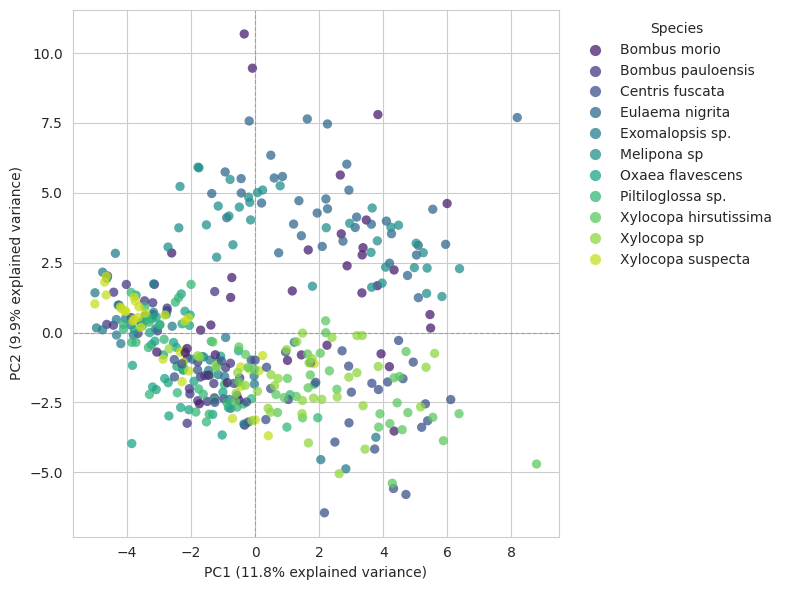

Saved PCA figure: /content/Figure_2a_PCA_species.png


In [15]:
# --- 16) PCA scatterplot colored by species (Viridis palette) ---
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

species_order = [
    "Bombus morio",
    "Bombus pauloensis",
    "Centris fuscata",
    "Eulaema nigrita",
    "Exomalopsis sp.",
    "Melipona sp",
    "Oxaea flavescens",
    "Piltiloglossa sp.",
    "Xylocopa hirsutissima",
    "Xylocopa sp",
    "Xylocopa suspecta"
]

species_order = [sp for sp in species_order if sp in pca_df["Specie"].unique()]
species_palette = dict(zip(species_order, sns.color_palette("viridis", n_colors=len(species_order))))

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Specie",
    hue_order=species_order,
    palette=species_palette,
    s=45,
    alpha=0.75,
    linewidth=0
)

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.xlabel(f"PC1 ({pc1_var:.1f}% explained variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% explained variance)")
#plt.title("PCA of acoustic features")

plt.legend(
    title="Species",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False,
    markerscale=1.2
)

plt.tight_layout()

pca_fig_path = "/content/Figure_1a_PCA_species.png"
plt.savefig(pca_fig_path, dpi=600, bbox_inches="tight")

plt.show()

print(f"Saved PCA figure: {pca_fig_path}")

In [11]:
# --- 17) t-SNE projection using all acoustic features ---
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "Dim1": X_tsne[:, 0],
    "Dim2": X_tsne[:, 1],
    "Specie": df["Specie"].values,
    "Type": df["Type"].values
})

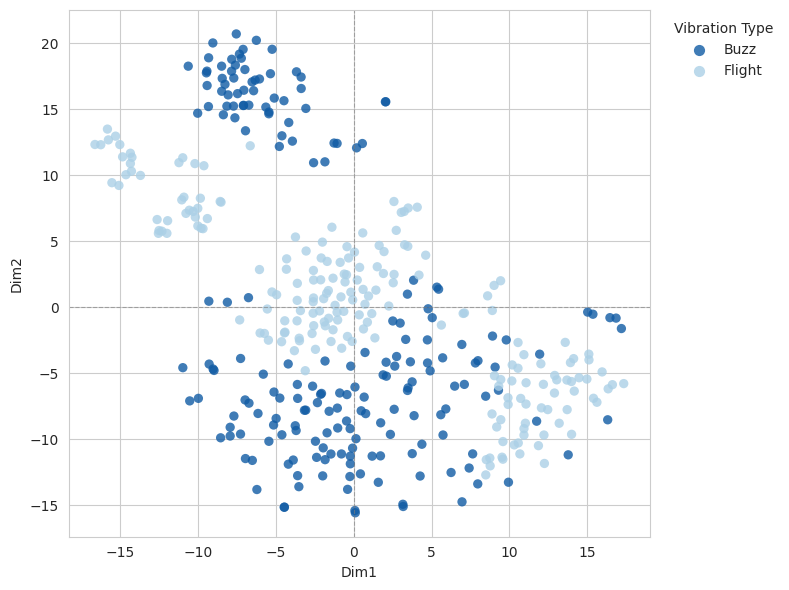

Saved t-SNE figure: /content/Figure_2b_tSNE_type.png


In [16]:
# --- 18) t-SNE scatterplot colored by vibration type ---
sns.set_style("whitegrid")

type_unique = list(pd.unique(tsne_df["Type"]))

if len(type_unique) == 2:
    type_palette = {
        type_unique[0]: sns.color_palette("Blues", 5)[4],
        type_unique[1]: sns.color_palette("Blues", 5)[1]
    }
else:
    type_palette = dict(zip(type_unique, sns.color_palette("viridis", n_colors=len(type_unique))))

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="Dim1",
    y="Dim2",
    hue="Type",
    palette=type_palette,
    s=45,
    alpha=0.8,
    linewidth=0
)

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.xlabel("Dim1")
plt.ylabel("Dim2")
#plt.title("t-SNE of acoustic features")

plt.legend(
    title="Vibration Type",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False,
    markerscale=1.2
)

plt.tight_layout()

tsne_fig_path = "/content/Figure_1b_tSNE_type.png"
plt.savefig(tsne_fig_path, dpi=600, bbox_inches="tight")

plt.show()

print(f"Saved t-SNE figure: {tsne_fig_path}")

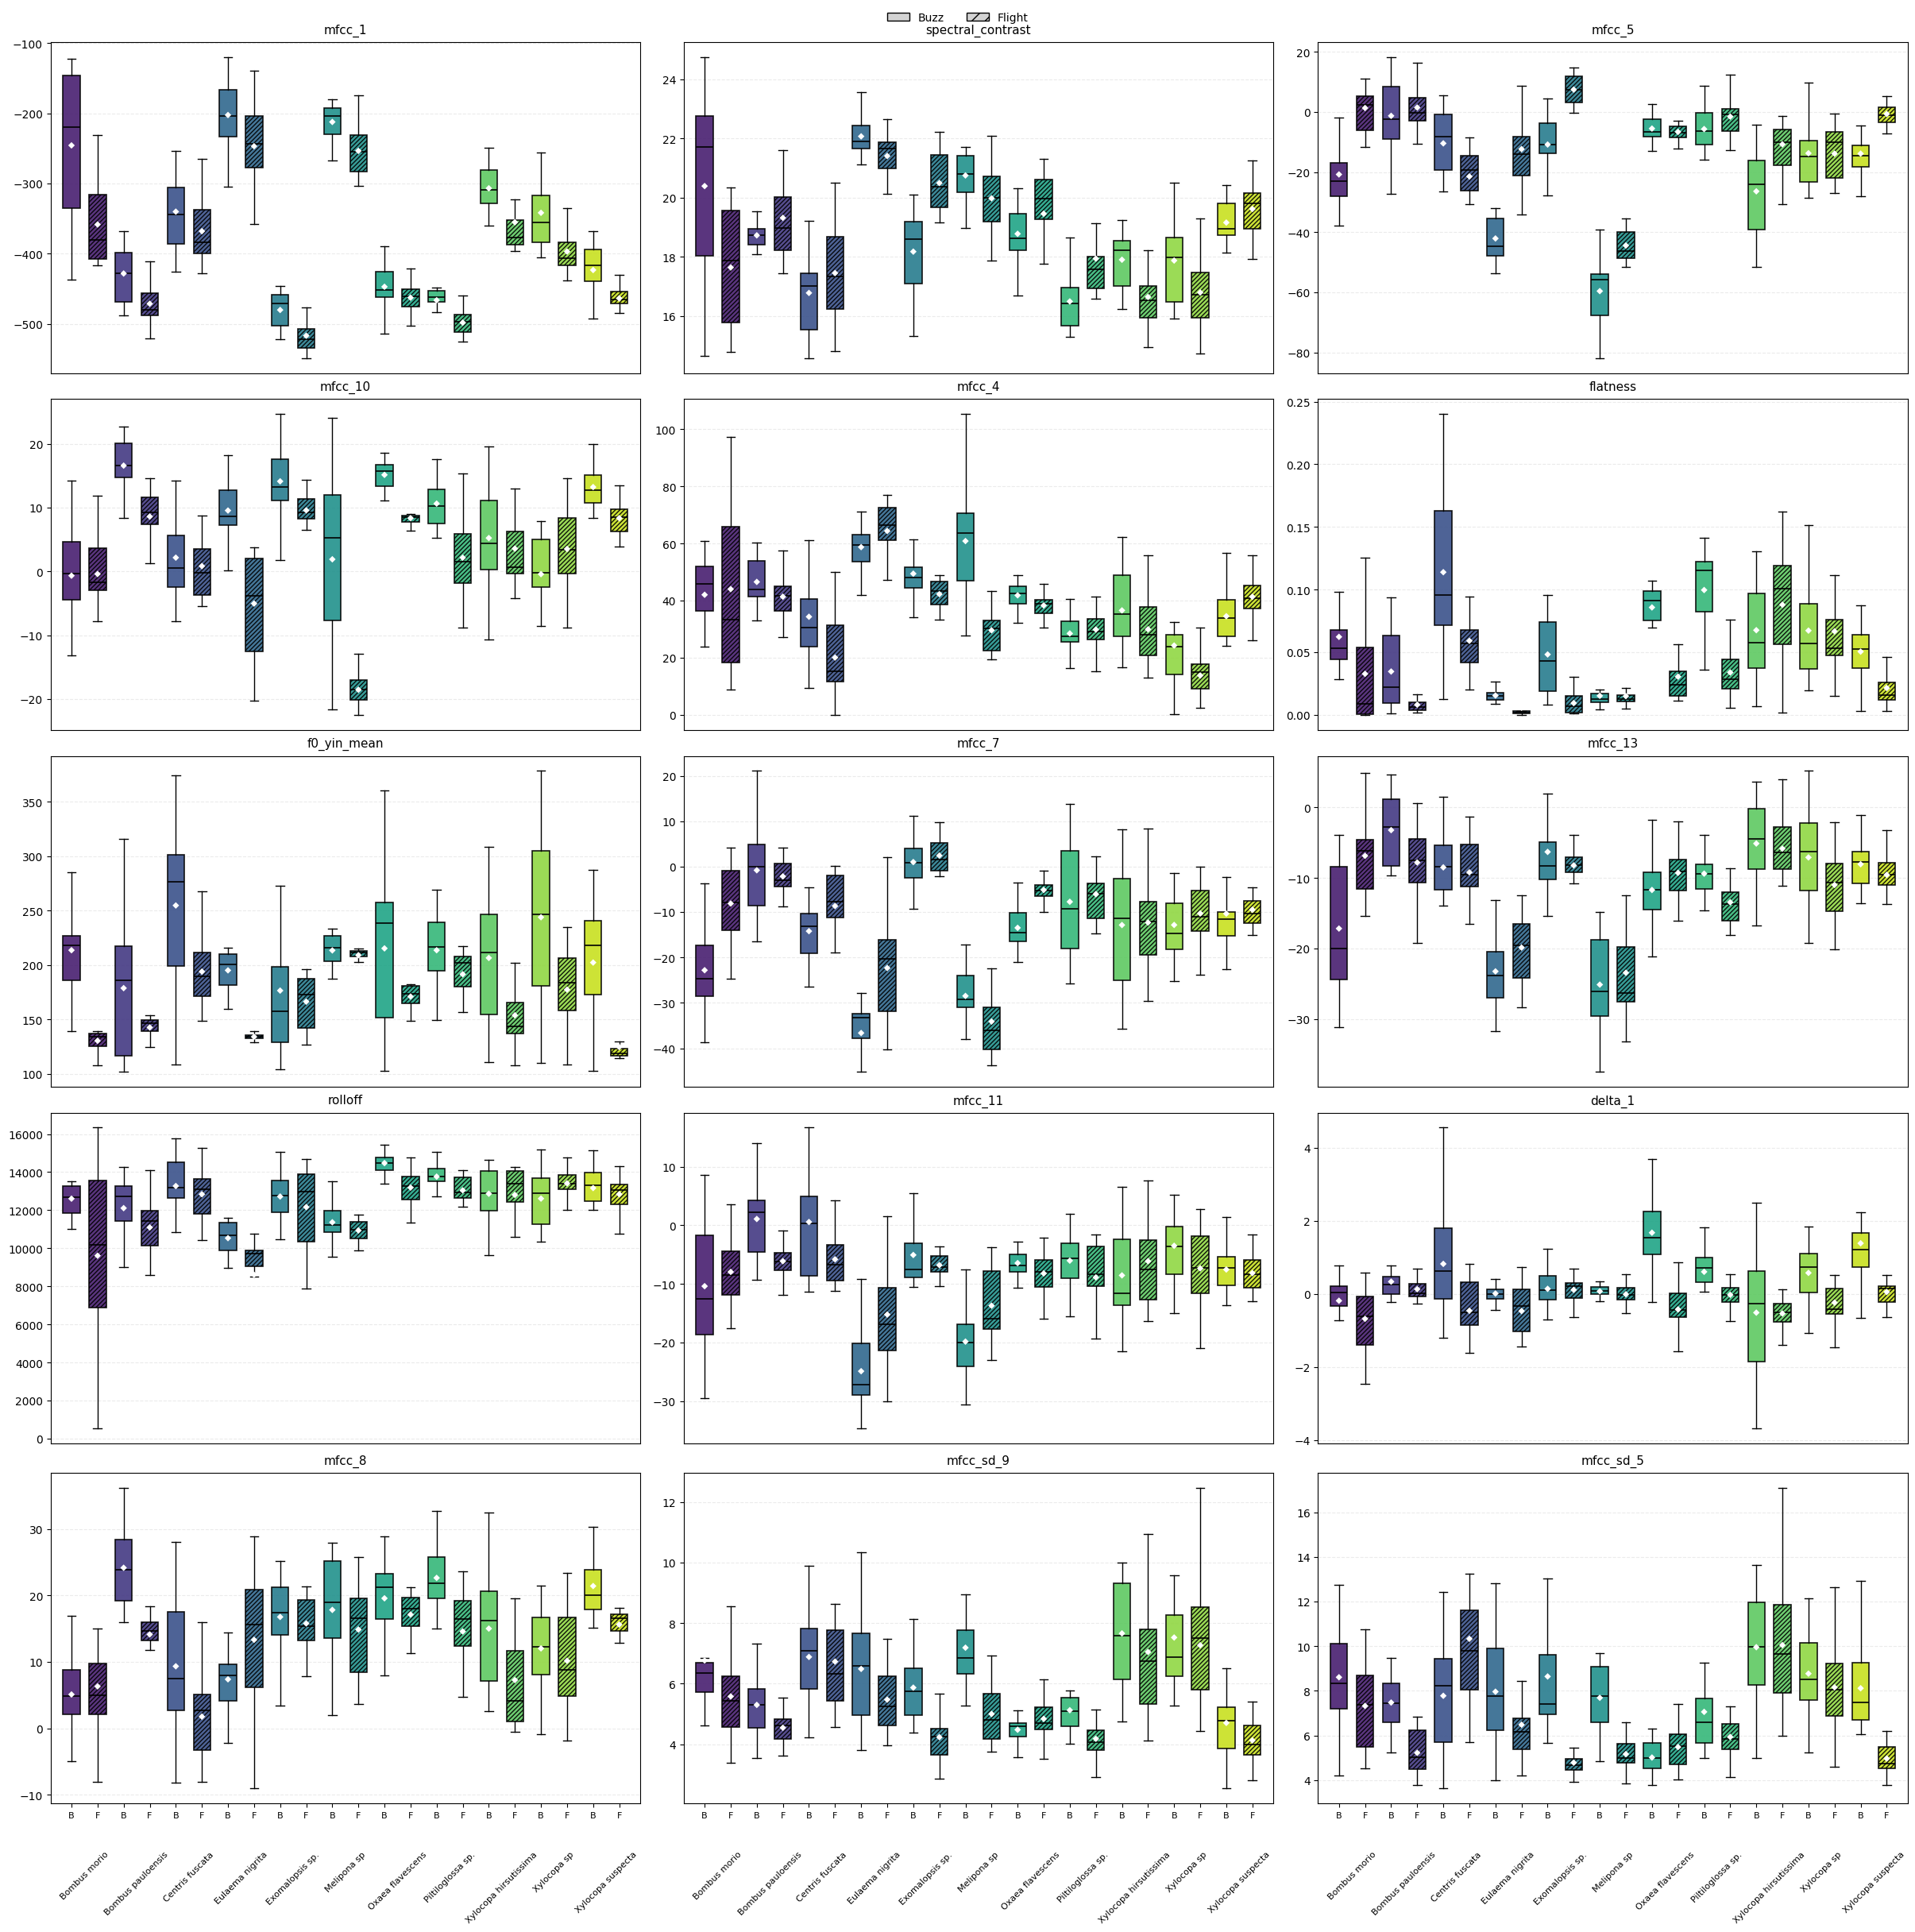

Saved: /content/Figure_S1_selected_features_boxplots.png


In [8]:
from matplotlib.patches import Patch

# --- 19) Boxplot grid for the selected features by species and behavioural context ---

# Final selected acoustic descriptors
SELECTED_FEATURES = [
    'mfcc_1',
    'spectral_contrast',
    'mfcc_5',
    'mfcc_10',
    'mfcc_4',
    'flatness',
    'f0_yin_mean',
    'mfcc_7',
    'mfcc_13',
    'rolloff',
    'mfcc_11',
    'delta_1',
    'mfcc_8',
    'mfcc_sd_9',
    'mfcc_sd_5'
]

# --- Optional: define explicit species order to match the manuscript ---
# If you prefer the order in the dataframe, comment this block and use pd.unique(df["Specie"])
species_order = [
    "Bombus morio",
    "Bombus pauloensis",
    "Centris fuscata",
    "Eulaema nigrita",
    "Exomalopsis sp.",
    "Melipona sp",
    "Oxaea flavescens",
    "Piltiloglossa sp.",
    "Xylocopa hirsutissima",
    "Xylocopa sp",
    "Xylocopa suspecta"
]

# Keep only species present in the dataframe
species_order = [sp for sp in species_order if sp in df["Specie"].unique()]

# --- Standardize behavioural labels just enough for ordering ---
type_unique = list(pd.unique(df["Type"]))
type_map = {str(t).strip().lower(): t for t in type_unique}

# Tries to keep Buzz first, Flight second
if "buzz" in type_map and "flight" in type_map:
    type_order = [type_map["buzz"], type_map["flight"]]
else:
    # fallback: preserve dataframe order
    type_order = type_unique[:2]

# --- Viridis palette by species ---
species_palette = dict(zip(species_order, sns.color_palette("viridis", n_colors=len(species_order))))

# Behaviour styles: same species colour, different hatch
type_hatch = {
    type_order[0]: "",      # e.g. Buzz
    type_order[1]: "//////"     # e.g. Flight
}

# --- 20) Create a 5 x 4 grid (adjust automatically if number of features changes) ---
n_features = len(SELECTED_FEATURES)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 4.8 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

for idx, feature in enumerate(SELECTED_FEATURES):
    ax = axes[idx]

    positions = []
    data = []
    box_colors = []
    box_hatches = []

    pos = 1
    species_centers = []

    for sp in species_order:
        pair_positions = []

        for tp in type_order:
            vals = df.loc[(df["Specie"] == sp) & (df["Type"] == tp), feature].dropna().values

            if len(vals) > 0:
                data.append(vals)
                positions.append(pos)
                box_colors.append(species_palette[sp])
                box_hatches.append(type_hatch[tp])
                pair_positions.append(pos)

            pos += 1

        if len(pair_positions) == 2:
            species_centers.append(np.mean(pair_positions))
        elif len(pair_positions) == 1:
            species_centers.append(pair_positions[0])

    # Draw boxplots
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.65,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        boxprops=dict(linewidth=1.0),
    )

    # Apply colours and hatches
    for patch, color, hatch in zip(bp["boxes"], box_colors, box_hatches):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)
        patch.set_alpha(0.9)
        patch.set_hatch(hatch)

    # Add mean as white diamond (similar visual cue to your previous figure)
    means = [np.mean(arr) for arr in data]
    ax.scatter(positions, means, marker="D", s=18, color="white", edgecolor="none", zorder=3)

    # Titles and aesthetics
    ax.set_title(feature, fontsize=11, pad=8)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_xlim(0.2, max(positions) + 0.8)

    # X labels only on bottom row to reduce clutter
    if idx < (nrows - 1) * ncols:
        ax.set_xticks([])
    else:
        # Minor labels: B / F
        minor_labels = []
        for _sp in species_order:
            minor_labels.extend(["B", "F"])
        ax.set_xticks(range(1, len(minor_labels) + 1))
        ax.set_xticklabels(minor_labels, fontsize=8)

        # Species labels centered below each pair
        y0, y1 = ax.get_ylim()
        y_text = y0 - 0.14 * (y1 - y0)

        for center, sp in zip(species_centers, species_order):
            ax.text(
                center, y_text, sp,
                ha="center", va="top",
                rotation=45, fontsize=8,
                transform=ax.transData
            )

    # Remove x-axis label text
    ax.set_xlabel("")

# Remove empty panels if fewer than grid size
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

# --- 19) Behaviour legend only (species already identified on x-axis) ---
legend_handles = [
    Patch(facecolor="lightgray", edgecolor="black", hatch="", label=f"{type_order[0]}"),
    Patch(facecolor="lightgray", edgecolor="black", hatch="//", label=f"{type_order[1]}")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01)
)

# --- 21) Save figure ---
supp_fig_path = "/content/Figure_S1_selected_features_boxplots.png"
plt.savefig(supp_fig_path, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {supp_fig_path}")